In [15]:
import sys
from pathlib import Path

# add parent folder to python path
sys.path.append(str(Path.cwd().parent))

In [16]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [17]:
import os
import json
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F

from utils import   show_images
from tqdm import tqdm
from data_handlers.datasets import CamusDataset
from utils.file_management import serialize_config,get_version_folder
from utils.augmentation import Augmentations
from model import EncoderDecoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [18]:
root = 'cache/model_weights/supplementary_vector'
index_folder = get_version_folder(root)

In [19]:
config= {
    'lr': 1e-4,
    'epochs': 10,
    'batch_size' : 32,
    'transformations' :None,
    'model_path':os.path.join(index_folder,'model.pt'),
    'samples_path':os.path.join(index_folder,'samples'),
    'bottleneck_dim':1024,
    'number_of_frames':1,
    'number_of_vectors':64,
    'add_checkboard':False
}

config_json= serialize_config(config)
with open(os.path.join(index_folder,'config.json'),'w') as f:
    json.dump(config_json,f,indent=2)


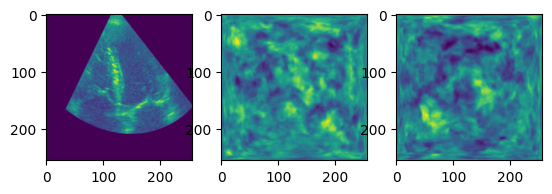

In [32]:
model = EncoderDecoder(bottleneck_dim=config['bottleneck_dim'],
                        number_of_vectors = config['number_of_vectors'],
                    output_heads=[1,1],
                        save_path = config['model_path']).to(device)

                 
optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])

dataset = CamusDataset(get_label=True)
train_loader = torch.utils.data.DataLoader(dataset, batch_size=config['batch_size'], shuffle=True)
losses =[]

augmentations = Augmentations(add_checkboard=config['add_checkboard'])
data,annotation = next(iter(train_loader))
data = augmentations(data)
data = data.to(device)[:,0]
with torch.no_grad():
    rec,seg= model(data)
show_images([data[0],rec[0]*seg[0],rec[1]*seg[1]])


In [21]:
epochs  =10
for epoch in range(epochs):
    loop = tqdm(train_loader,desc=f'Epoch {epoch}/{epochs}')
    for data in loop:
        data = augmentations(data)
        optimizer.zero_grad()
        frame = data[:,0].to(device)    
        rec,seg= model(frame)
       
        heads = seg.shape[1]
        
        loss = 0
     
        for i in range(heads):
            for j in range(i+1,heads):
                loss += (1/heads**2)*(seg[:,i]*seg[:,j]).mean()

        reconstruction = torch.sum(seg*rec,dim=1).unsqueeze(1)
        loss += 20*F.mse_loss(reconstruction,frame)
      
        loss.backward()
        optimizer.step()
        losses.append(loss.item()) 
        loop.set_postfix(loss=loss.item())
    torch.save(model.state_dict(), model.save_path)

Epoch 9/10: 100%|██████████| 276/276 [01:30<00:00,  3.05it/s, loss=0.181]


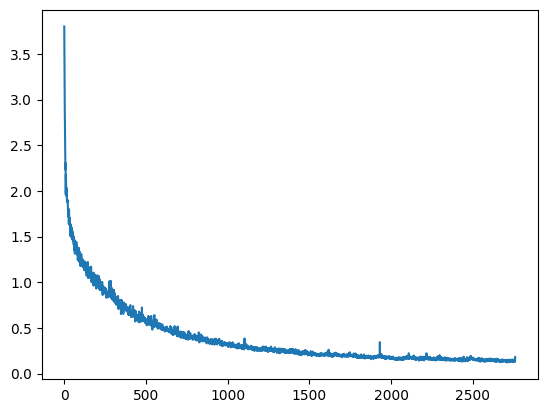

In [22]:
plt.plot(losses)

In [42]:
model.load_state_dict(torch.load('cache/model_weights/supplementary_vector/2/model.pt'))

<All keys matched successfully>

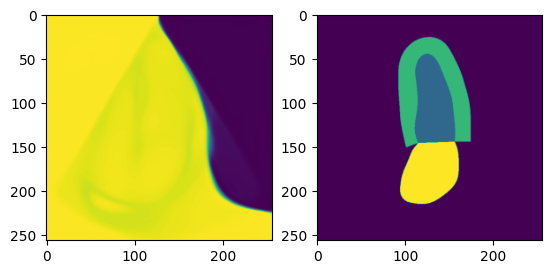

In [72]:
data ,annotation= next(iter(train_loader))

frame = augmentations(data,train=False)[:,0].to(device)
with torch.no_grad():
    rec,seg= model(frame)
    reconstruction = torch.sum(seg*rec,dim=1).unsqueeze(1)
# show_images([frame[0],reconstruction[0],seg[:,0],seg[:,1],annotation])

show_images([seg[:,0],annotation])
